# Logistic Regression from Scratch

Implementing Logistic Regression from scratch using NumPy on a simple 2D binary classification dataset.


## Objective

In this notebook, we will implement **Logistic Regression from scratch using NumPy**.

The purpose is not simply to make a classifier work. Instead, this notebook is a foundation for understanding the complete classification pipeline before moving to **Softmax Regression on MNIST**.

### Learning objectives

By the end of this notebook, we should understand:

* how a linear model produces a score from input features
* the role of weights and bias
* how the sigmoid function converts a score into a probability
* how Binary Cross Entropy measures prediction error
* how gradients are derived
* how gradient descent updates model parameters
* how the complete training loop works
* how Logistic Regression produces a linear decision boundary
* how to evaluate the resulting classifier

The implementation will use **NumPy** for the model and training process and **Matplotlib** for visualization.


## Architecture

It is important to distinguish between the **model architecture** and the **training process**.

### Model — Forward Pass

The model transforms an input into a probability:

```text
Input Features
      ↓
Linear Transformation
      ↓
z = XW + b
      ↓
Sigmoid
      ↓
Probability
```

The linear transformation produces a score:

$$
z = XW + b
$$

The sigmoid function then converts this score into a value between 0 and 1:

$$
p = \sigma(z)
$$

where \(p\) represents the predicted probability of the positive class.

### Training

Training is the process used to adjust the model parameters:

```text
Prediction + True Labels
          ↓
  Binary Cross Entropy
          ↓
        Loss
          ↓
       Gradient
          ↓
  Gradient Descent
          ↓
 Updated Parameters
          ↓
    Forward Pass
```

This process is repeated for many iterations.

### Why keep these separate?

The **forward pass describes what the model does**.

The **training process describes how the model learns its parameters**.

This distinction will remain important when we later move from:

```text
Logistic Regression
        ↓
Softmax Regression
        ↓
       MLP
        ↓
       CNN
        ↓
       ViT
```

The model architecture will change, but many training concepts such as loss, gradients, optimization, and evaluation can be reused.


## Module 1 — Dataset

Before implementing Logistic Regression, we need data for the model to learn from.

Instead of starting immediately with MNIST, we will first use a simple **2D binary classification dataset**.

Each sample will contain two features:

$$
x = [x_1, x_2]
$$

and each sample belongs to one of two classes:

$$
y \in \{0,1\}
$$

We will generate two groups of points:

* Class 0 centered around \((2,2)\)
* Class 1 centered around \((6,6)\)

Because the data has only two features, we can visualize it directly on a 2D plot.

This will later allow us to visualize the **linear decision boundary learned by Logistic Regression**.


In [37]:
import numpy as np
import matplotlib.pyplot as plt

In [38]:
np.random.seed(42) # makes it reproducible

n_samples = 100

X_class0 = np.random.randn(n_samples, 2) + np.array([2, 2])
X_class1 = np.random.randn(n_samples, 2) + np.array([6, 6])

X = np.vstack([X_class0, X_class1])

y = np.hstack([
    np.zeros(n_samples),
    np.ones(n_samples)
])

In [39]:
# test print
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFirst 5 samples:")
print(X[:5])

print("\nFirst 5 labels:")
print(y[:5])

X shape: (200, 2)
y shape: (200,)

First 5 samples:
[[2.49671415 1.8617357 ]
 [2.64768854 3.52302986]
 [1.76584663 1.76586304]
 [3.57921282 2.76743473]
 [1.53052561 2.54256004]]

First 5 labels:
[0. 0. 0. 0. 0.]


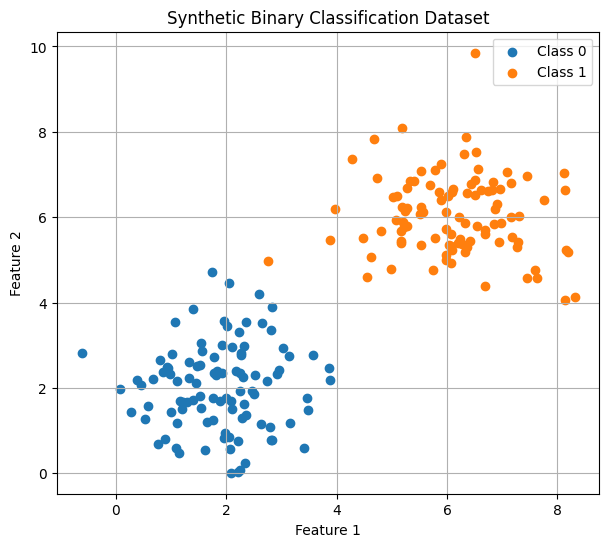

In [40]:
#Visualize
plt.figure(figsize=(7, 6))

plt.scatter(
    X_class0[:, 0],
    X_class0[:, 1],
    label="Class 0"
)

plt.scatter(
    X_class1[:, 0],
    X_class1[:, 1],
    label="Class 1"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Synthetic Binary Classification Dataset")
plt.legend()
plt.grid(True)
plt.show()

### Analysis

The dataset contains two classes distributed around different centers.

Because each sample has only two features, we can visually inspect the classification problem in 2D.

The important properties of the dataset are:

$$
X.shape = (200,2)
$$

$$
y.shape = (200,)
$$

This dataset is intentionally simple.

At this stage, the goal is not to create a difficult classification problem. The goal is to make the mechanics of Logistic Regression easy to see.

Later, after training the model, we should be able to visualize a **linear decision boundary** separating the two classes.

This is much harder to visualize directly on MNIST because MNIST samples have:

$$
28 \times 28 = 784
$$

input features.

Therefore, this synthetic dataset acts as a small conceptual environment where we can understand the model before increasing the problem complexity.


## Module 2 — Preprocessing

Before sending the data into the model, we will standardize the input features.

Our two features currently have different numerical scales and distributions. Standardization transforms each feature so that it has approximately:

$$
\text{mean} = 0
$$

and

$$
\text{standard deviation} = 1
$$

The standardization formula is:

$$
X_{\text{scaled}} = \frac{X-\mu}{\sigma}
$$

where:

* $\mu$ is the mean of the feature
* $\sigma$ is the standard deviation of the feature

### Why standardize?

Gradient Descent updates parameters based on gradients.

When features have very different scales, the optimization landscape can become poorly conditioned, which can make learning less efficient.

By putting the features onto a similar scale, Gradient Descent can generally optimize the parameters more smoothly.

For this simple dataset, standardization is also useful because it gives us a clean example of a preprocessing step that can be reused later in more complex models.


In [41]:
# calculate
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)

print("Feature means:", X_mean)
print("Feature standard deviations:", X_std)

Feature means: [4.00634223 4.03875499]
Feature standard deviations: [2.32388035 2.22381885]


In [42]:
X = (X - X_mean) / X_std

In [43]:
print("Mean after standardization:", X.mean(axis=0))
print("Std after standardization:", X.std(axis=0))

Mean after standardization: [-3.67483821e-16 -1.11355369e-15]
Std after standardization: [1. 1.]


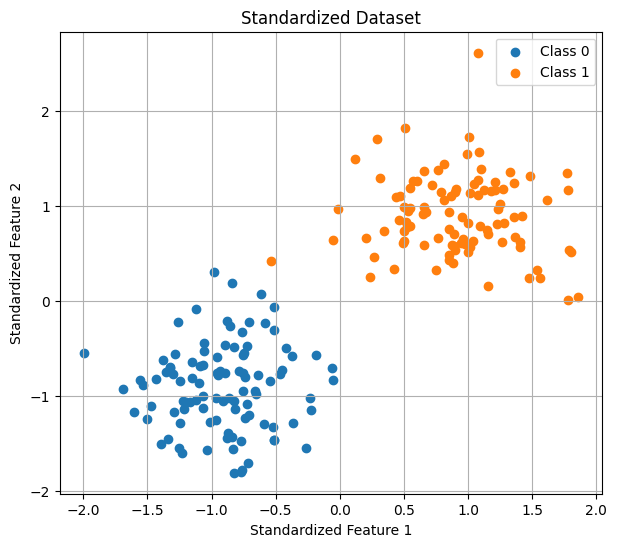

In [44]:
# visualize
plt.figure(figsize=(7, 6))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1"
)

plt.xlabel("Standardized Feature 1")
plt.ylabel("Standardized Feature 2")
plt.title("Standardized Dataset")
plt.legend()
plt.grid(True)
plt.show()

### Analysis

After standardization, each input feature has approximately zero mean and unit standard deviation:

$$
\mu \approx 0
$$

$$
\sigma \approx 1
$$

The relative arrangement of the samples is preserved, but the coordinate system has been rescaled.

This preprocessing step does **not** change the class labels.

The model will still receive the same classification problem:

$$
X \rightarrow y
$$

but the numerical representation of \(X\) is now more suitable for Gradient Descent.

### Important distinction

Standardization changes the **representation of the input**, not the model itself.

The Logistic Regression architecture remains:

$$
z = XW+b
$$

followed by:

$$
p = \sigma(z)
$$

So preprocessing belongs to the data pipeline, while the next module will define the actual model.


## Module 3 — Logistic Regression Model

We now define the actual Logistic Regression model.

The model takes an input vector \(x\), computes a linear score, and converts that score into a probability.

The complete forward computation is:

$$
z = x^T w + b
$$

followed by

$$
p = \sigma(z)
$$

where:

* $x$ is the input feature vector
* $w$ is the weight vector
* $b$ is the bias
* $z$ is the linear score, also called the **logit**
* $p$ is the predicted probability of class $1$

For a dataset containing $N$ samples, we can perform the computation for all samples at once:

$$
Z = XW+b
$$

and then:

$$
P = \sigma(Z)
$$

This gives one probability for every sample.


In [45]:
W = np.zeros(2)
b = 0.0

print("W:", W)
print("b:", b)

W: [0. 0.]
b: 0.0


In [46]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [47]:
# foward pass
z = X @ W + b
p = sigmoid(z)

print("z shape:", z.shape)
print("p shape:", p.shape)

print("\nFirst 5 logits:")
print(z[:5])

print("\nFirst 5 probabilities:")
print(p[:5])

z shape: (200,)
p shape: (200,)

First 5 logits:
[0. 0. 0. 0. 0.]

First 5 probabilities:
[0.5 0.5 0.5 0.5 0.5]


In [48]:
print("Unique logits:", np.unique(z))
print("Unique probabilities:", np.unique(p))

Unique logits: [0.]
Unique probabilities: [0.5]


In [49]:
#predict
def predict_proba(X, W, b):
    z = X @ W + b
    return sigmoid(z)


def predict(X, W, b):
    probabilities = predict_proba(X, W, b)
    return (probabilities >= 0.5).astype(int)

### Analysis

The Logistic Regression model can be summarized mathematically as:

$$
\boxed{
P=\sigma(XW+b)
}
$$

The model consists of two computational steps.

First, a linear transformation:

$$
Z=XW+b
$$

Then, a nonlinear output transformation:

$$
P=\sigma(Z)
$$

The linear transformation determines a score for each sample. The sigmoid maps that score into the interval \((0,1)\), allowing it to be interpreted as a modeled probability for class 1.

The trainable parameters are:

$$
W
$$

and

$$
b
$$

At initialization, both were set to zero, producing:

$$
Z=0
$$

and:

$$
P=0.5
$$

for every sample.

This means the initial model has not learned a preference for either class.

A classification threshold of \(0.5\) gives:

$$
P\geq0.5\Rightarrow\hat y=1
$$

and:

$$
P<0.5\Rightarrow\hat y=0
$$

Because the sigmoid is monotonic, this is equivalent to thresholding the linear score at zero:

$$
Z=0
$$

which gives the decision boundary:

$$
w_1x_1+w_2x_2+b=0
$$

Therefore Logistic Regression remains a **linear classifier**, even though the sigmoid function itself is nonlinear.

### Important components that we now have

```text
Input
  ↓
Linear Transformation
  XW + b
  ↓
Logit
  Z
  ↓
Sigmoid
  ↓
Probability
  P
  ↓
Threshold
  ↓
Predicted Class
```

The model itself is now complete.

What is still missing is the mechanism that tells us **how wrong the model is** and therefore **how $W$ and $b$ should change**.

That will be the purpose of the next module: Binary Cross Entropy.


## Module 4 — Binary Cross Entropy

The Logistic Regression model produces a probability $p$ representing the predicted probability that a sample belongs to class $1$.

However, a prediction alone does not tell us whether the model is performing well.

We therefore need a **loss function** that measures the difference between:

* the true label $y$
* the predicted probability $p$

For binary classification, we use **Binary Cross Entropy (BCE)**.

For one sample, the loss is:

$$
L = -\left[y\log(p) + (1-y)\log(1-p)\right]
$$

For $N$ samples, we take the average:

$$
L =
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

This is the loss function that will tell us how well our Logistic Regression model is predicting the data.


In [50]:
def binary_cross_entropy(y_true, y_pred):
    epsilon = 1e-15

    # log(0) is inf so we gotta do something about it, make the p != 0 or 1
    y_pred = np.clip(
        y_pred,
        epsilon,
        1 - epsilon
    )

    loss = -np.mean(
        y_true * np.log(y_pred)
        + (1 - y_true) * np.log(1 - y_pred)
    )

    return loss

In [51]:
# test the loss func

y_test = np.array([1, 1, 0, 0])

predictions_good = np.array([
    0.99, 0.90, 0.10, 0.01
])

predictions_uncertain = np.array([
    0.60, 0.55, 0.45, 0.40
])

predictions_bad = np.array([
    0.01, 0.10, 0.90, 0.99
])

print(
    "Good predictions:",
    binary_cross_entropy(y_test, predictions_good)
)

print(
    "Uncertain predictions:",
    binary_cross_entropy(y_test, predictions_uncertain)
)

print(
    "Bad predictions:",
    binary_cross_entropy(y_test, predictions_bad)
)

Good predictions: 0.05770542575566387
Uncertain predictions: 0.5543313122608056
Bad predictions: 3.4538776394910684


In [52]:
# test good so we go for it
p = predict_proba(X, W, b)

loss = binary_cross_entropy(y, p)

print("Initial loss:", loss)

Initial loss: 0.6931471805599452


### Analysis

Binary Cross Entropy provides a quantitative measure of how well the predicted probabilities agree with the true labels.

For one sample:

$$
L =
-\left[
y\log(p)+(1-y)\log(1-p)
\right]
$$

For the full dataset:

$$
L=
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

The loss is small when the model assigns a high probability to the correct class.

The loss becomes very large when the model is confidently wrong.

An important interpretation is that BCE is the **negative log-likelihood** of the observed labels under the probabilities predicted by the model.

At initialization, we set:

$$
W=0,\qquad b=0
$$

which gives:

$$
z=0
$$

and therefore:

$$
p=\sigma(0)=0.5
$$

for every sample.

Consequently, the initial loss is approximately:

$$
-\log(0.5)\approx0.6931
$$

This gives us a baseline from which training can improve.

### Current pipeline

```text
Input X
   ↓
Linear Transformation
   Z = XW + b
   ↓
Sigmoid
   P = sigmoid(Z)
   ↓
Binary Cross Entropy
   ↓
Loss
```

The model can now produce both predictions and a numerical measure of error.

The remaining question is:

> Given the loss, how should $W$ and $b$ change to make the loss smaller?

That question leads directly to the gradient derivation in the next module.


## Module 5 — Gradient / Backpropagation

The model currently produces predictions and a loss:

$$
Z = XW+b
$$

$$
P=\sigma(Z)
$$

$$
L=L_{\mathrm{BCE}}(P,Y)
$$

To train the model, we need to determine how the loss changes with respect to the parameters $W$ and $b$.

Using the chain rule, the gradients for Logistic Regression with Sigmoid + Binary Cross Entropy are:

$$
\frac{\partial L}{\partial Z}=P-Y
$$

$$
dW=
\frac{1}{N}X^T(P-Y)
$$

$$
db=
\frac{1}{N}\sum_{i=1}^{N}(P_i-Y_i)
$$

The derivation of these equations is documented separately in `docs/02_logistic_regression.md`.

Here, the notebook focuses on connecting the equations to the implementation.


### Backward Pass

The training computation can be viewed as:

```text
Loss
  ↓
∂L/∂Z = P - Y
  ↓
∂L/∂W
∂L/∂b
```

The quantity $P-Y$ is the prediction error.

It is propagated backward to determine how the parameters should be changed.


In [53]:
def compute_gradients(X, y, p):
    N = X.shape[0]

    error = p - y

    dW = (X.T @ error) / N
    db = np.mean(error)

    return dW, db

In [54]:
p = predict_proba(X, W, b)

dW, db = compute_gradients(X, y, p)

print("dW:", dW)
print("db:", db)

dW: [-0.45654383 -0.450741  ]
db: 0.0


In [55]:
# Grad Check
epsilon = 1e-5

W_plus = W.copy()
W_plus[0] += epsilon

W_minus = W.copy()
W_minus[0] -= epsilon

loss_plus = binary_cross_entropy(
    y,
    predict_proba(X, W_plus, b)
)

loss_minus = binary_cross_entropy(
    y,
    predict_proba(X, W_minus, b)
)

numerical_dW1 = (loss_plus - loss_minus) / (2 * epsilon)

print("Analytical dW[0]:", dW[0])
print("Numerical dW[0]: ", numerical_dW1)
print("Difference:", abs(dW[0] - numerical_dW1))

Analytical dW[0]: -0.4565438339795114
Numerical dW[0]:  -0.4565438339876326
Difference: 8.121170402830558e-12


### Gradient Check

We derived the analytical gradient mathematically:

$$
\frac{\partial L}{\partial W}
=
\frac{1}{N}X^T(P-Y)
$$

Our implementation calculates this gradient directly:

```python
dW = (X.T @ (p - y)) / N
```

To verify that this implementation is correct, we independently approximate the derivative numerically using the **central finite difference**:

$$
\frac{\partial L}{\partial w_j}
\approx
\frac{
L(w_j+\epsilon)-L(w_j-\epsilon)
}{
2\epsilon
}
$$

For the first weight $w_1$, this becomes:

$$
\frac{\partial L}{\partial w_1}
\approx
\frac{
L(w_1+\epsilon)-L(w_1-\epsilon)
}{
2\epsilon
}
$$

The numerical gradient does **not** use our analytical gradient formula. Instead, it slightly perturbs the parameter in both directions, evaluates the resulting loss, and estimates the slope from the change in loss.

Therefore, we compare two independently obtained values:

```text
Analytical gradient
        ↓
  derived mathematically
        ↓
dW = Xᵀ(P-Y) / N


Numerical gradient
        ↓
  finite difference
        ↓
[L(w₁+ε) - L(w₁-ε)] / 2ε
```

If the two values are very close:

$$
\text{analytical gradient}
\approx
\text{numerical gradient}
$$

then we have strong evidence that our mathematical derivation and its implementation are correct.

A small difference is expected because the numerical gradient is only an approximation and is affected by floating-point precision.


### Analysis

The backward pass converts the model's prediction error into gradients for the trainable parameters.

The key relationship is:

$$
P-Y
$$

which is used to compute:

$$
dW=\frac{1}{N}X^T(P-Y)
$$

and:

$$
db=\frac{1}{N}\sum_{i=1}^{N}(P_i-Y_i)
$$

The model can now calculate both its loss and the direction in which its parameters should change.

The next module will use these gradients with Gradient Descent to update $W$ and $b$.


## Module 6 — Optimization: Gradient Descent

We now have a way to calculate how the loss changes with respect to each model parameter:

$$
dW = \frac{\partial L}{\partial W}
$$

$$
db = \frac{\partial L}{\partial b}
$$

However, calculating the gradient alone does not change the model parameters.

We need an optimization method to update the parameters in a direction that reduces the loss.

### Gradient Descent

Gradient descent updates each parameter by moving in the opposite direction of its gradient:

$$
W \leftarrow W-\eta dW
$$

$$
b \leftarrow b-\eta db
$$

where $\eta$ is the **learning rate**.

The gradient points toward the direction of increasing loss, so subtracting the gradient moves the parameters toward a lower loss.

The learning rate controls the size of each update:

* A very small learning rate produces slow updates.
* A very large learning rate can cause the optimization to overshoot the minimum or become unstable.
* An appropriate learning rate allows the model to gradually reduce the loss.

### Optimization Flow

Our complete optimization step is therefore:

$$
X,Y
\rightarrow
P
\rightarrow
L
\rightarrow
(dW,db)
\rightarrow
(W,b)\text{ update}
$$

The updated parameters are then used in the next forward pass.


In [56]:
def update_parameters(W, b, dW, db, learning_rate):
    W = W - learning_rate * dW
    b = b - learning_rate * db

    return W, b

In [57]:
# test
learning_rate = 0.1

# Forward pass
p = predict_proba(X, W, b)

# Compute gradients
dW, db = compute_gradients(X, y, p)

# Update parameters
W_new, b_new = update_parameters(
    W, b, dW, db, learning_rate
)

print("Old W:", W)
print("New W:", W_new)

print("\nOld b:", b)
print("New b:", b_new)

Old W: [0. 0.]
New W: [0.04565438 0.0450741 ]

Old b: 0.0
New b: 0.0


In [58]:
# check loss
loss_before = binary_cross_entropy(y, p)

print("Loss before update:", loss_before)

Loss before update: 0.6931471805599452


In [59]:
p_new = predict_proba(X, W_new, b_new)

loss_after = binary_cross_entropy(y, p_new)

print("Loss after update:", loss_after)

Loss after update: 0.6529221427877423


### Observation

Starting from the initial parameters $W=0$ and $b=0$, the model initially predicts approximately $0.5$ for every sample, giving a binary cross-entropy loss of approximately $0.693$.

After one gradient descent update, the parameters change according to the computed gradients. The resulting predictions produce a lower loss.

This demonstrates the basic optimization cycle:

$$
\text{parameters}
\rightarrow
\text{predictions}
\rightarrow
\text{loss}
\rightarrow
\text{gradient}
\rightarrow
\text{parameter update}
$$

The process can then be repeated many times to progressively reduce the loss.


## Module 7 — Training

We now have all the components required to train the Logistic Regression model:

* A forward pass that produces predictions.
* Binary Cross Entropy to measure the loss.
* Analytical gradients for $W$ and $b$.
* Gradient descent to update the parameters.

Training consists of repeatedly applying these steps.

### Training Loop

For each iteration:

1. Compute predictions using the current parameters.
2. Compute the loss.
3. Compute the gradients.
4. Update $W$ and $b$.
5. Store the loss for later analysis.

Mathematically:

$$
P = \sigma(XW+b)
$$

$$
L = \mathrm{BCE}(Y,P)
$$

$$
dW = \frac{1}{N}X^T(P-Y)
$$

$$
db = \frac{1}{N}\sum_{i=1}^{N}(P_i-Y_i)
$$

Then update the parameters:

$$
W \leftarrow W-\eta dW
$$

$$
b \leftarrow b-\eta db
$$

This process is repeated for a fixed number of iterations.

The goal of training is to find parameters $W$ and $b$ that minimize the loss:

$$
\min_{W,b} L(W,b)
$$


In [60]:
W = np.zeros(X.shape[1])
b = 0.0

print("Initial W:", W)
print("Initial b:", b)

Initial W: [0. 0.]
Initial b: 0.0


In [61]:
learning_rate = 0.1
num_iterations = 1000

loss_history = []

for iteration in range(num_iterations):

    # Forward pass
    p = predict_proba(X, W, b)

    # Compute loss
    loss = binary_cross_entropy(y, p)

    # Compute gradients
    dW, db = compute_gradients(X, y, p)

    # Update parameters
    W, b = update_parameters(
        W, b, dW, db, learning_rate
    )

    # Store loss
    loss_history.append(loss)

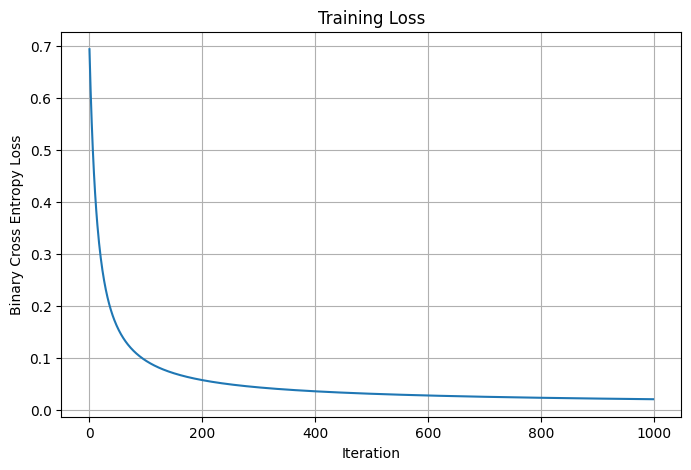

In [62]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(loss_history)

plt.xlabel("Iteration")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Training Loss")

plt.grid(True)
plt.show()

In [63]:
print("Final W:", W)
print("Final b:", b)
print("Final loss:", loss_history[-1])

Final W: [2.9759942  3.02178104]
Final b: 0.02188436340100216
Final loss: 0.020261935634042896


In [64]:
final_predictions = predict_proba(X, W, b)
final_loss = binary_cross_entropy(y, final_predictions)

print("Final loss after training:", final_loss)

Final loss after training: 0.020250418811443113


### Observation

The training loss decreases over the iterations, indicating that gradient descent is successfully adjusting the model parameters to produce predictions that better match the training labels.

The training process repeatedly performs:

$$
\text{Forward Pass}
\rightarrow
\text{Loss}
\rightarrow
\text{Gradient}
\rightarrow
\text{Parameter Update}
$$

As training progresses, the parameters $W$ and $b$ change, which changes the model's predictions and therefore the loss.

The loss curve provides a simple way to visualize this optimization process. A decreasing curve indicates that the optimization is moving toward a region of lower loss.

The training loop therefore combines all previously implemented modules into one complete learning process.


## Module 8 — Evaluation

After training the model, we need to measure how well it classifies the samples.

The model produces probabilities:

$$
P=\sigma(XW+b)
$$

These probabilities are converted into binary predictions using a threshold of $0.5$:

$$
\hat{y}=
\begin{cases}
1 & P\geq0.5\\
0 & P<0.5
\end{cases}
$$

The predicted labels $\hat{y}$ can then be compared with the true labels $y$.

### Accuracy

Accuracy measures the proportion of correctly classified samples:

$$
\mathrm{Accuracy}
=
\frac{\text{number of correct predictions}}
{\text{total number of predictions}}
$$

Equivalently:

$$
\mathrm{Accuracy}
=
\frac{1}{N}
\sum_{i=1}^{N}
\mathbf{1}(\hat{y}_i=y_i)
$$

where $\mathbf{1}(\cdot)$ equals $1$ when the prediction is correct and $0$ otherwise.

### Confusion Matrix

For binary classification, predictions can be divided into four categories:

|                 |            Actual 0 |            Actual 1 |
| --------------- | ------------------: | ------------------: |
| **Predicted 0** |  True Negative (TN) | False Negative (FN) |
| **Predicted 1** | False Positive (FP) |  True Positive (TP) |

These four quantities provide more detailed information than accuracy alone.

From them we can calculate:

$$
\mathrm{Precision}
=
\frac{TP}{TP+FP}
$$

$$
\mathrm{Recall}
=
\frac{TP}{TP+FN}
$$

and:

$$
F1
=
2\frac{\mathrm{Precision}\cdot\mathrm{Recall}}
{\mathrm{Precision}+\mathrm{Recall}}
$$

For this simple balanced synthetic dataset, accuracy is sufficient as a primary metric, while the additional metrics demonstrate the standard evaluation framework for binary classification.


In [65]:
predictions = predict(X, W, b)

print("Predictions:", predictions[:20])
print("True labels:", y[:20])

Predictions: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
True labels: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


In [66]:
accuracy = np.mean(predictions == y)

print("Accuracy:", accuracy)

Accuracy: 0.995


In [67]:
# Calc Confuse Matrix
TP = np.sum((predictions == 1) & (y == 1))
TN = np.sum((predictions == 0) & (y == 0))
FP = np.sum((predictions == 1) & (y == 0))
FN = np.sum((predictions == 0) & (y == 1))

print("True Positives :", TP)
print("True Negatives :", TN)
print("False Positives:", FP)
print("False Negatives:", FN)

True Positives : 99
True Negatives : 100
False Positives: 0
False Negatives: 1


In [68]:
precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0.0

if precision + recall > 0:
    f1 = 2 * precision * recall / (precision + recall)
else:
    f1 = 0.0

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 1.0
Recall: 0.99
F1 Score: 0.9949748743718593


In [69]:
confusion_matrix = np.array([
    [TN, FN],
    [FP, TP]
])

print(confusion_matrix)

[[100   1]
 [  0  99]]


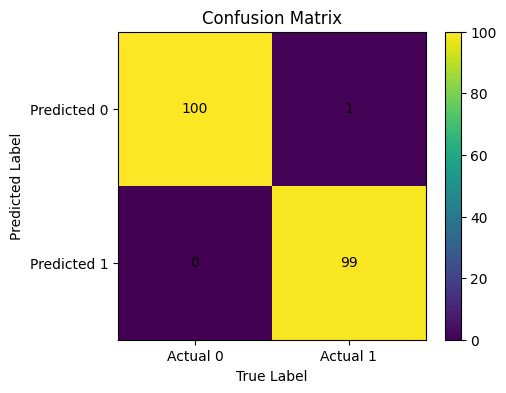

In [70]:
plt.figure(figsize=(5, 4))

plt.imshow(confusion_matrix)

plt.xticks([0, 1], ["Actual 0", "Actual 1"])
plt.yticks([0, 1], ["Predicted 0", "Predicted 1"])

plt.xlabel("True Label")
plt.ylabel("Predicted Label")
plt.title("Confusion Matrix")

for i in range(2):
    for j in range(2):
        plt.text(j, i, confusion_matrix[i, j],
                 ha="center", va="center")

plt.colorbar()
plt.show()

### Observation

The trained Logistic Regression model can now be evaluated using its final predictions.

Accuracy provides an overall measure of correct classifications, while the confusion matrix shows the types of errors made by the model.

Precision measures how many predicted positive samples are actually positive, while recall measures how many actual positive samples were successfully identified.

The F1 score combines precision and recall into a single metric.

For the current synthetic dataset, the model should achieve high classification performance because the two classes are well separated and can be separated using a linear decision boundary.

The evaluation stage does not modify the model parameters. It only measures the performance of the already-trained model.


## Module 9 — Decision Boundary

Logistic Regression produces a probability through the sigmoid function:

$$
p=\sigma(z)
$$

For binary classification, we classify a sample as class 1 when:

$$
p\geq0.5
$$

The sigmoid function satisfies:

$$
\sigma(0)=0.5
$$

Therefore, the classification boundary occurs when:

$$
z=0
$$

Since:

$$
z=w_1x_1+w_2x_2+b
$$

the decision boundary is:

$$
w_1x_1+w_2x_2+b=0
$$

Solving for $x_2$ gives:

$$
x_2=-\frac{w_1x_1+b}{w_2}
$$

This is a straight line, which demonstrates an important property of Logistic Regression:

> Although the sigmoid function is nonlinear, the decision boundary of Logistic Regression is linear in the original input features.

The trained weights determine the orientation of the boundary, while the bias determines its position.


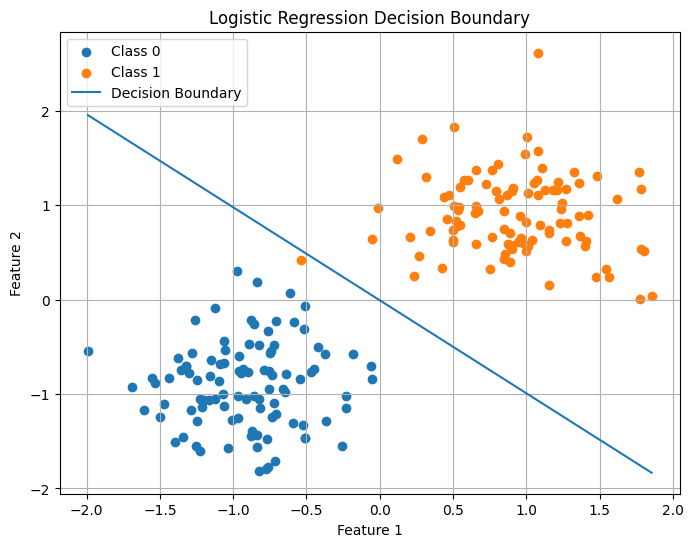

In [71]:
plt.figure(figsize=(8, 6))

# Plot the two classes
plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1"
)

# Create x-values for the decision boundary
x1_values = np.linspace(
    X[:, 0].min(),
    X[:, 0].max(),
    100
)

# Calculate corresponding x2 values
x2_values = -(W[0] * x1_values + b) / W[1]

# Plot decision boundary
plt.plot(
    x1_values,
    x2_values,
    label="Decision Boundary"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.grid(True)

plt.show()

### Observation

The trained Logistic Regression model produces a linear decision boundary:

$$
w_1x_1+w_2x_2+b=0
$$

The visualization shows that the learned boundary separates the two classes in the feature space.

Samples on one side of the boundary have:

$$
z>0
$$

and are classified as class 1, while samples on the other side have:

$$
z<0
$$

and are classified as class 0.

This provides a geometric interpretation of the model parameters: the weights determine the orientation of the decision boundary, while the bias shifts its position.

The visualization also demonstrates why Logistic Regression is considered a linear classifier.


## Module 10 — Experiments

The previous modules established a complete Logistic Regression training pipeline. We now investigate how training behavior changes when we modify important hyperparameters.

The two hyperparameters examined here are:

1. Learning rate $\eta$
2. Number of training iterations

The experiments use the same dataset and model structure so that changes in the results can be attributed to the parameter being investigated.

### Experimental Principle

To study the effect of one hyperparameter, the other conditions should remain fixed.

For example, when comparing different learning rates, we keep the dataset, initialization, and number of iterations unchanged.

The main quantity used to compare training behavior is the Binary Cross Entropy loss:

$$
L=-\frac{1}{N}\sum_{i=1}^{N}
\left[
y_i\log(p_i)+(1-y_i)\log(1-p_i)
\right]
$$

A successful optimization process should generally reduce the loss over time.


In [72]:
def train_logistic_regression(
    X,
    y,
    learning_rate,
    num_iterations
):
    W = np.zeros(X.shape[1])
    b = 0.0

    loss_history = []

    for iteration in range(num_iterations):

        # Forward pass
        p = predict_proba(X, W, b)

        # Loss
        loss = binary_cross_entropy(y, p)

        # Gradients
        dW, db = compute_gradients(X, y, p)

        # Update parameters
        W, b = update_parameters(
            W, b, dW, db, learning_rate
        )

        # Store loss
        loss_history.append(loss)

    return W, b, loss_history

In [73]:
# func test
W_test, b_test, loss_history_test = train_logistic_regression(
    X,
    y,
    learning_rate=0.1,
    num_iterations=1000
)

print("Final W:", W_test)
print("Final b:", b_test)
print("Final loss:", loss_history_test[-1])

Final W: [2.9759942  3.02178104]
Final b: 0.02188436340100216
Final loss: 0.020261935634042896


In [74]:
# test learn rate
learning_rates = [0.001, 0.01, 0.1, 1.0]

results = {}

for learning_rate in learning_rates:

    W_exp, b_exp, loss_history = train_logistic_regression(
        X,
        y,
        learning_rate=learning_rate,
        num_iterations=1000
    )

    results[learning_rate] = {
        "W": W_exp,
        "b": b_exp,
        "loss_history": loss_history
    }

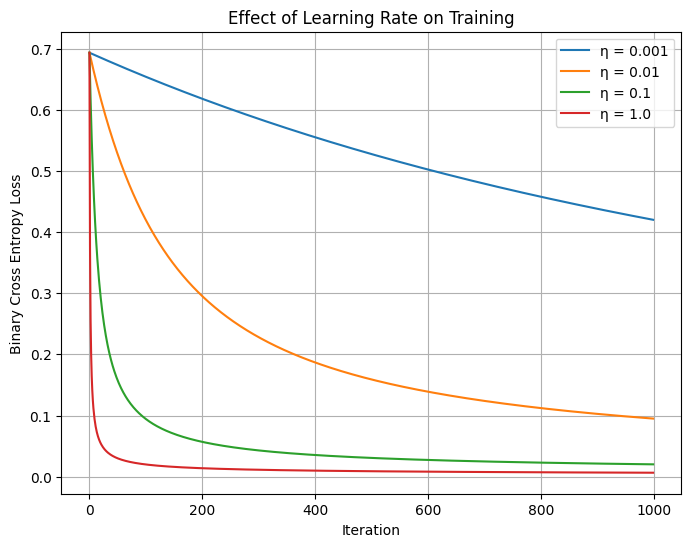

In [75]:
plt.figure(figsize=(8, 6))

for learning_rate in learning_rates:
    plt.plot(
        results[learning_rate]["loss_history"],
        label=f"η = {learning_rate}"
    )

plt.xlabel("Iteration")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Effect of Learning Rate on Training")
plt.legend()
plt.grid(True)

plt.show()

In [76]:
for learning_rate in learning_rates:
    final_loss = results[learning_rate]["loss_history"][-1]

    print(
        f"Learning rate = {learning_rate:<5} "
        f"| Final loss = {final_loss:.6f}"
    )

Learning rate = 0.001 | Final loss = 0.420053
Learning rate = 0.01  | Final loss = 0.095058
Learning rate = 0.1   | Final loss = 0.020262
Learning rate = 1.0   | Final loss = 0.006549


In [77]:
# test iteration
iteration_counts = [100, 500, 1000]

iteration_results = {}

for num_iterations in iteration_counts:

    W_exp, b_exp, loss_history = train_logistic_regression(
        X,
        y,
        learning_rate=0.1,
        num_iterations=num_iterations
    )

    iteration_results[num_iterations] = {
        "W": W_exp,
        "b": b_exp,
        "loss_history": loss_history
    }

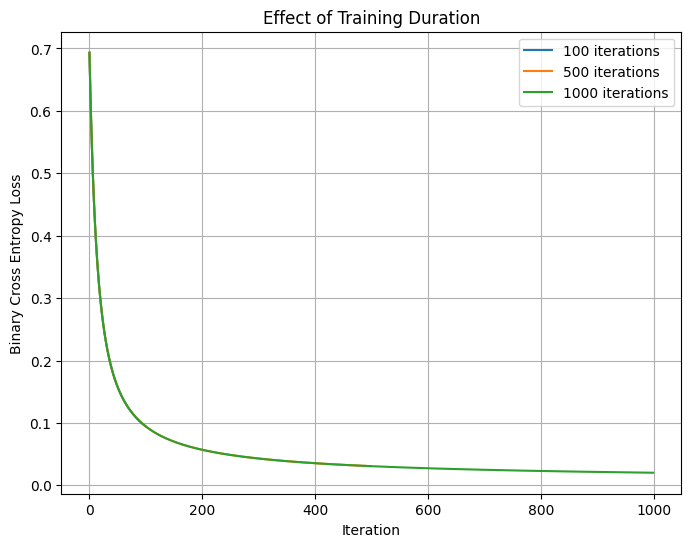

In [78]:
plt.figure(figsize=(8, 6))

for num_iterations in iteration_counts:
    plt.plot(
        iteration_results[num_iterations]["loss_history"],
        label=f"{num_iterations} iterations"
    )

plt.xlabel("Iteration")
plt.ylabel("Binary Cross Entropy Loss")
plt.title("Effect of Training Duration")
plt.legend()
plt.grid(True)

plt.show()

### Experimental Analysis

#### Experiment A — Learning Rate

The learning rate controls the magnitude of each gradient descent update:

$$
W\leftarrow W-\eta dW
$$

When $\eta$ is very small, the parameters change slowly, causing the loss to decrease more gradually.

Increasing the learning rate produces larger parameter updates and can accelerate convergence. However, excessively large updates can cause unstable optimization or prevent the loss from decreasing smoothly.

From the observed loss curves, the learning rates tested in this experiment show different convergence behaviors.

#### Experiment B — Number of Iterations

Increasing the number of iterations gives gradient descent more opportunities to update the model parameters.

The loss generally decreases rapidly during the earlier iterations and then begins to flatten as the model approaches a lower-loss region.

This demonstrates that training duration and learning rate are separate factors:

* The learning rate determines **how large each update is**.
* The number of iterations determines **how many updates are performed**.

### Experimental Conclusion

The experiments demonstrate that hyperparameters affect the behavior of the optimization process even though the underlying Logistic Regression model remains unchanged.

The model architecture is therefore independent from the optimization settings used to train it.


## Module 11 — Conclusion

We have implemented a complete Logistic Regression classifier from scratch using NumPy.

The implementation was developed as a sequence of independent modules:

$$
\boxed{
\text{Dataset}
\rightarrow
\text{Preprocessing}
\rightarrow
\text{Model}
\rightarrow
\text{Loss}
\rightarrow
\text{Gradient}
\rightarrow
\text{Optimization}
\rightarrow
\text{Training}
\rightarrow
\text{Evaluation}
}
$$

### What We Implemented

The model computes predictions using:

$$
Z=XW+b
$$

$$
P=\sigma(Z)
$$

where the sigmoid function is:

$$
\sigma(z)=\frac{1}{1+e^{-z}}
$$

The predictions are evaluated using Binary Cross Entropy:

$$
L=
-\frac{1}{N}
\sum_{i=1}^{N}
\left[
y_i\log(p_i)
+
(1-y_i)\log(1-p_i)
\right]
$$

The gradients are:

$$
dW=\frac{1}{N}X^T(P-Y)
$$

$$
db=\frac{1}{N}\sum_{i=1}^{N}(P_i-Y_i)
$$

and the parameters are optimized using gradient descent:

$$
W\leftarrow W-\eta dW
$$

$$
b\leftarrow b-\eta db
$$

The trained model can then produce class predictions and be evaluated using accuracy, precision, recall, F1 score, and a confusion matrix.

### What We Learned

The implementation demonstrates the complete relationship between the mathematical formulation of a machine learning model and its numerical implementation.

In particular, the training process can be summarized as:

$$
\text{Forward Pass}
\rightarrow
\text{Loss}
\rightarrow
\text{Gradient}
\rightarrow
\text{Parameter Update}
$$

Repeating this process allows the model parameters to gradually move toward values that produce lower loss.


### From Binary to Multiclass Classification

The Logistic Regression model developed above is designed for binary classification.

Its output is a single probability:

$$
p=P(y=1\mid x)
$$

which represents the probability that an input belongs to class $1$.

This works naturally when there are only two classes:

$$
y\in\{0,1\}
$$

However, the MNIST dataset contains ten digit classes:

$$
y\in\{0,1,2,\ldots,9\}
$$

For MNIST, the model needs to produce ten class probabilities for each input rather than a single binary probability.

This motivates the transition from **Logistic Regression** to **Softmax Regression**.

Instead of producing one probability with the sigmoid function, Softmax Regression produces a probability distribution over all classes:

$$
P(y=k\mid x)
$$

for:

$$
k\in\{0,1,\ldots,9\}
$$

The ten probabilities must satisfy:

$$
\sum_{k=0}^{9}P(y=k\mid x)=1
$$

This provides a natural representation of the model's confidence across all possible digit classes.


### Logistic Regression → Softmax Regression

The transition to Softmax Regression does not require rebuilding the entire machine learning pipeline.

Many components remain conceptually the same.

| Component             | Logistic Regression    | Softmax Regression                |
| --------------------- | ---------------------- | --------------------------------- |
| Input                 | Feature vector $x$     | Feature vector $x$                |
| Linear transformation | $z=x^TW+b$             | $z=x^TW+b$                        |
| Output activation     | Sigmoid                | Softmax                           |
| Output                | One probability        | One probability per class         |
| Loss                  | Binary Cross Entropy   | Multiclass Cross Entropy          |
| Gradient descent      | Same principle         | Same principle                    |
| Training loop         | Same structure         | Same structure                    |
| Evaluation            | Classification metrics | Multiclass classification metrics |

The main conceptual changes are therefore:

$$
\boxed{
\text{Sigmoid}
\rightarrow
\text{Softmax}
}
$$

and:

$$
\boxed{
\text{Binary Cross Entropy}
\rightarrow
\text{Multiclass Cross Entropy}
}
$$

The output representation also changes from one probability to a probability vector.

This modular structure allows the Softmax Regression implementation to reuse many ideas from the Logistic Regression implementation while replacing the components that are specific to binary classification.


### Architecture Comparison

#### Logistic Regression

For a binary problem:

$$
x
\rightarrow
x^TW+b
\rightarrow
\text{Sigmoid}
\rightarrow
p
\rightarrow
\hat y
$$

The model produces one probability.

#### Softmax Regression

For a $K$-class problem:

$$
x
\rightarrow
XW+b
\rightarrow
\text{Softmax}
\rightarrow
[p_1,p_2,\ldots,p_K]
\rightarrow
\hat y
$$

For MNIST, $K=10$:

$$
[p_0,p_1,p_2,\ldots,p_9]
$$

The predicted class is the class with the largest probability:

$$
\hat y=\arg\max_k p_k
$$

Thus, Softmax Regression extends the same linear classification idea to multiple classes.


## Final Conclusion

This notebook implemented Logistic Regression from scratch using NumPy, beginning with a simple two-dimensional binary classification problem.

The implementation connected the mathematical concepts of:

* linear transformation,
* sigmoid activation,
* Binary Cross Entropy,
* analytical gradients,
* gradient descent,
* iterative training,
* and classification evaluation.

The experiments also demonstrated how optimization hyperparameters influence the training process.

The most important structural observation is that the complete training pipeline can be divided into reusable modules. The model, loss function, gradient calculation, optimization process, training loop, and evaluation can be considered as separate components.

This modular structure will be reused in the next stage of the project.

The next model is **Softmax Regression on MNIST**. It will retain the fundamental linear-classification and gradient-descent concepts developed here, while replacing the binary output mechanism with a multiclass probability distribution.

The next stage therefore builds directly upon the concepts and implementation developed in this notebook rather than starting from scratch.
